# Part 2 통합 — 지형(DEM) 데이터 전처리 (전체 파이프라인)

2026-08-31 2개 노트북을 실행 순서대로 하나로 합친 버전. 원본은 각각 별도 파일로 남아있고, 이 노트북은 전체 흐름을 한 번에 보고 재현하기 위한 통합본이다.

**실행 순서 (파일 의존성 기준)**

| 구간 | 원본 노트북 | 역할 | 핵심 산출물 |
|---|---|---|---|
| A | `part2_DEM_격자병합.ipynb` | 구별 DEM을 H3 hex 격자(hex_id) 기준으로 병합한다. | Part 2 최종 입력 테이블 |
| B | `part2_terrain_raster_export.ipynb` | 구간 A의 격자·표고 결과를 바탕으로 보류됐던 100m 래스터(.tif)를 생성한다. | 변수별 GeoTIFF |

구간 B는 구간 A의 산출물(hex 격자 · 표고 테이블)을 읽어서 쓰므로 반드시 구간 A 다음에 실행해야 한다. 구간 경계에서 `%reset -f`로 네임스페이스를 초기화해 앞 구간 변수가 뒷 구간에 실수로 섞여 들어가지 않게 했다.


---
# 구간 A. 구별 DEM → H3 격자 병합
**원본: `part2_DEM_격자병합.ipynb`**

구별 DEM을 H3 hex 격자(hex_id) 기준으로 병합해 Part 2 최종 입력 테이블을 만든다.

# Part 2. 구별 DEM → H3 격자(hex_id) 병합

**목표**: 확보한 구별 DEM(`.img`, ERDAS Imagine 포맷)을 Part 1에서 만든 H3 res10 헥사곤 격자(`hex_id`)에 맞춰 표고(elevation) 테이블로 변환한다.

**진행 순서**
1. `data/part2` 아래 각 구 폴더를 스캔해서 도엽(`.img`) 파일을 전부 찾는다. 한 구가 도엽 여러 장에 걸쳐 있으면 전부 모은다.
2. 구별로 도엽이 여러 장이면 `rasterio.merge`로 자동 모자이크해서 하나의 래스터처럼 다룬다.
3. 각 구 DEM에서 유효 픽셀을 테이블(x, y, elev_m)로 추출한다.
4. 행정동 경계(`BND_ADM_DONG_PG.shp`)로 구 경계를 만들고, 그 구에 속하는 hex만 골라 DEM 값을 샘플링해서 `hex_id` 기준 표고 테이블을 만든다.
5. 그 구를 실제로 얼마나 덮는지(`valid_frac`)를 기준으로 `ready` 여부를 판정해서, 통과한 구만 최종 Part 2 입력 테이블로 저장한다. 도엽이 새로 추가되면 **이 노트북을 처음부터 재실행하기만 하면 자동으로 반영**되도록 설계했다 (구 이름을 하드코딩하지 않고 폴더를 스캔함).

> 📌 배경: 처음 받은 8개 구 폴더 중 강서를 제외한 7개 구가 전부 `35913`(도엽명 "부산") 한 장만 갖고 있었다. 이 도엽은 부산 내부 구(수영·연제·해운대)는 완전히 덮었지만, 다른 시와 접경한 구(금정↔양산, 기장↔울산, 사상·사하↔김해)는 일부만 덮었다 — **행정구역 경계와 도엽(지도 인덱스) 경계가 다르기 때문에**, 접경 구는 "부산"이라는 이름의 도엽 하나로는 부족하고 옆 도시 이름의 인접 도엽까지 받아야 한다. 접경 구들이 추가 도엽(양산 35909, 방어진 35910, 학리 35914, 34804 등)을 받으면서, 여러 도엽을 자동 모자이크하도록 파이프라인을 확장했고 현재 8개 구 전부 `ready` 상태다.

## 0. 준비

In [1]:
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.transform import xy as rio_xy
from rasterio.merge import merge as rio_merge
from rasterio.io import MemoryFile

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)


In [2]:
# 경로 설정 -----------------------------------------------------------
PROJECT_DIR = Path("..")  # 2026-08-16: 노트북이 notebooks/ 아래로 이동, 프로젝트 루트는 한 단계 위
BASE_DEM_DIR = PROJECT_DIR / "data" / "part2"  # 2026-08-16: data/전처리용 DEM -> data/part2 개명
DONG_SHP_PATH = PROJECT_DIR / "data" / "part1" / "행정동" / "BND_ADM_DONG_PG.shp"  # 2026-08-16: data/행정동 -> data/part1/행정동
HEX_GPKG_PATH = PROJECT_DIR / "data" / "지표면 온도 데이터" / "tables" / "busan_hex_r10.gpkg"
TABLES_OUT_DIR = PROJECT_DIR / "data" / "지표면 온도 데이터" / "tables"

assert BASE_DEM_DIR.exists(), f"DEM 폴더를 찾을 수 없음: {BASE_DEM_DIR.resolve()}"
assert DONG_SHP_PATH.exists(), f"행정동 경계 파일을 찾을 수 없음: {DONG_SHP_PATH.resolve()}"
assert HEX_GPKG_PATH.exists(), f"hex 격자 파일을 찾을 수 없음: {HEX_GPKG_PATH.resolve()}"


In [3]:
# 부산 16개 구/군 - sgg_cd 매핑 (adm_dong_lut.csv / 행정동 경계 파일과 대조해 확인한 고정 코드)
# 지금 폴더가 없는 구는 나중에 DEM이 도착하면 자동으로 처리된다 (아래에서 실제 존재하는 폴더만 스캔하기 때문).
GU_SGG_MAP = {
    "중구": "21010", "서구": "21020", "동구": "21030", "영도": "21040",
    "부산진": "21050", "동래": "21060", "남구": "21070", "북구": "21080",
    "해운대": "21090", "사하": "21100", "금정": "21110", "강서": "21120",
    "연제": "21130", "수영": "21140", "사상": "21150", "기장": "21510",
}


## 1. 구 경계 & hex 격자 로드

In [4]:
# 행정동 경계(전국) 로드 -> 부산만 필터 -> 구 단위로 dissolve
# 원본 dbf 인코딩이 CP949라 encoding 인자를 꼭 넘겨줘야 한글이 깨지지 않는다.
dong = gpd.read_file(DONG_SHP_PATH, encoding="cp949")
dong["sgg_cd"] = dong["ADM_CD"].astype(str).str[:5]
dong_busan = dong[dong["ADM_CD"].astype(str).str.startswith("21")].copy()

gu_boundary = dong_busan.dissolve(by="sgg_cd")[["geometry"]].reset_index()
print(f"부산 {len(gu_boundary)}개 구/군 경계 생성 완료 (dong CRS: {dong.crs})")


부산 16개 구/군 경계 생성 완료 (dong CRS: EPSG:5186)


In [5]:
# H3 res10 hex 격자 (Part 1 산출물) 로드
hex_gdf = gpd.read_file(HEX_GPKG_PATH, columns=["hex_id", "sgg_cd", "adm_nm", "in_busan", "elev_m"])
print(f"hex 격자 {len(hex_gdf):,}개 로드 (CRS: {hex_gdf.crs})")
hex_gdf["sgg_cd"].value_counts(dropna=False).sort_index()


hex 격자 151,440개 로드 (CRS: EPSG:5186)


sgg_cd
21010      281
21020     1268
21030      884
21040     1296
21050     2672
21060     1510
21070     2405
21080     3399
21090     4695
21100     3578
21110     5799
21120    15435
21130     1077
21140      922
21150     3024
21510    19881
None     83314
Name: count, dtype: int64

## 2. 구별 DEM 파일 탐색 + 무결성 점검

`BASE_DEM_DIR` 아래 실제로 존재하는 구 폴더만 스캔한다. 폴더 이름은 `GU_SGG_MAP`의 키와 일치해야 매칭된다.
한 구가 도엽(지도 인덱스) 경계에 걸쳐 있으면 `.img` 파일이 여러 개일 수 있는데, 전부 찾아서 나중에 모자이크한다.

In [6]:
def md5_file(path: Path, chunk_size: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()


tile_records = []
for gu_dir in sorted(BASE_DEM_DIR.iterdir()):
    if not gu_dir.is_dir():
        continue
    gu = gu_dir.name
    if gu not in GU_SGG_MAP:
        print(f"[건너뜀] '{gu}' 폴더는 GU_SGG_MAP에 없는 이름입니다. 매핑을 확인하세요.")
        continue

    img_files = sorted(gu_dir.rglob("*.img"))
    if not img_files:
        print(f"[건너뜀] {gu}: .img 파일 없음")
        continue

    for img_path in img_files:
        tile_records.append({
            "gu": gu,
            "sgg_cd": GU_SGG_MAP[gu],
            "tile": img_path.stem,  # 도엽번호
            "img_path": str(img_path),
            "md5": md5_file(img_path),
        })

tile_files = pd.DataFrame(tile_records)
tile_files.sort_values(["gu", "tile"]).reset_index(drop=True)


[건너뜀] '__MACOSX' 폴더는 GU_SGG_MAP에 없는 이름입니다. 매핑을 확인하세요.


,gu,sgg_cd,tile,img_path,md5
0,강서,21120,35816,data\전처리용 DEM\강서\35816\35816.img,35b1f25d74104996e5d0663b18d41f76
1,금정,21110,35909,data\전처리용 DEM\금정\35909\35909.img,fe89fe05bd22e460536f7be59c34f486
2,금정,21110,35913,data\전처리용 DEM\금정\35913\35913.img,d790889f7dd9d5696c9405a044a6bc13
3,기장,21510,35909,data\전처리용 DEM\기장\35909\35909.img,fe89fe05bd22e460536f7be59c34f486
4,기장,21510,35910,data\전처리용 DEM\기장\35910\35910.img,5306bfe67f4c17d5ee0d93d1ddb11d85
5,기장,21510,35913,data\전처리용 DEM\기장\35913\35913.img,d790889f7dd9d5696c9405a044a6bc13
6,기장,21510,35914,data\전처리용 DEM\기장\35914\35914.img,e0d1e0c596c4899daf1111ed1d31bfd3
7,사상,21150,35816,data\전처리용 DEM\사상\35816\35816.img,35b1f25d74104996e5d0663b18d41f76
8,사상,21150,35913,data\전처리용 DEM\사상\35913\35913.img,d790889f7dd9d5696c9405a044a6bc13
9,사하,21100,34804,data\전처리용 DEM\사하\34804\34804.img,36f6dcd02693b7c7ee5d98bcb4ca0a59


In [7]:
# 같은 도엽(md5 동일)이 여러 구에서 나오는 건 이상한 게 아니다 -- 부산의 여러 구가
# 물리적으로 같은 지도 인덱스(도엽) 위에 걸쳐 있으면 당연히 같은 파일을 나눠 갖게 된다.
# (금정↔양산, 기장↔울산처럼 구 경계가 도엽 경계와 어긋나서, 접경 구는 도엽을 2장 이상 받아야 완전히 커버된다.)
dup_counts = tile_files["md5"].value_counts()
tile_files["shared_with_other_gu"] = tile_files["md5"].map(dup_counts) > 1

# 구 단위로 도엽들을 묶는다 (도엽이 여러 장이면 나중에 모자이크해서 하나의 래스터처럼 사용)
dem_files = (
    tile_files.groupby(["gu", "sgg_cd"], as_index=False)
    .agg(tiles=("tile", list), img_paths=("img_path", list), n_tiles=("img_path", "size"))
)

print(dem_files[["gu", "n_tiles", "tiles"]].sort_values("gu").to_string(index=False))
print()
print(tile_files[["gu", "tile", "shared_with_other_gu"]].sort_values(["gu", "tile"]).to_string(index=False))


 gu  n_tiles                        tiles
 강서        1                      [35816]
 금정        2               [35909, 35913]
 기장        4 [35909, 35910, 35913, 35914]
 사상        2               [35816, 35913]
 사하        3        [34804, 35816, 35913]
 수영        1                      [35913]
 연제        1                      [35913]
해운대        1                      [35913]

 gu  tile  shared_with_other_gu
 강서 35816                  True
 금정 35909                  True
 금정 35913                  True
 기장 35909                  True
 기장 35910                 False
 기장 35913                  True
 기장 35914                 False
 사상 35816                  True
 사상 35913                  True
 사하 34804                 False
 사하 35816                  True
 사하 35913                  True
 수영 35913                  True
 연제 35913                  True
해운대 35913                  True


### 2-1. 여러 도엽 자동 모자이크

구 하나가 도엽(`n_tiles`) 여러 장에 걸쳐 있으면 `rasterio.merge`로 하나의 래스터로 합쳐서 이후 단계(테이블 추출, hex 샘플링)에서는 도엽 개수를 신경 쓸 필요가 없게 한다.

In [8]:
def open_mosaic(img_paths):
    """도엽이 1장이면 그대로 열고, 여러 장이면 rasterio.merge로 모자이크해서 연다."""
    img_paths = [Path(p) for p in img_paths]
    if len(img_paths) == 1:
        return rasterio.open(img_paths[0])

    srcs = [rasterio.open(p) for p in img_paths]
    crs_set = {s.crs for s in srcs}
    if len(crs_set) > 1:
        raise ValueError(f"도엽들의 CRS가 서로 달라서 모자이크할 수 없음: {crs_set}")

    mosaic, out_transform = rio_merge(srcs)
    meta = srcs[0].meta.copy()
    meta.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2], transform=out_transform)
    for s in srcs:
        s.close()

    memfile = MemoryFile()
    dst = memfile.open(**meta)
    dst.write(mosaic)
    return dst


## 3. 각 구 DEM 테이블 추출 (요청 1)

DEM 래스터(도엽이 여러 장이면 모자이크)의 유효 픽셀(NoData 제외)을 `(x, y, elev_m)` 테이블로 변환해서 각 구 폴더에 저장한다.

In [9]:
def dem_to_table(img_paths):
    """DEM 래스터(도엽이 여러 장이면 모자이크)를 읽어서 유효 픽셀만 (x, y, elev_m) 테이블로 변환."""
    with open_mosaic(img_paths) as src:
        band = src.read(1).astype("float64")
        nodata = src.nodata
        valid_mask = band != nodata if nodata is not None else np.ones(band.shape, dtype=bool)
        rows, cols = np.where(valid_mask)
        xs, ys = rio_xy(src.transform, rows, cols)
        table = pd.DataFrame({"x": xs, "y": ys, "elev_m": band[rows, cols]})
        return table, src.crs


dem_table_summary = []
for _, row in dem_files.iterrows():
    gu, img_paths = row["gu"], row["img_paths"]
    table, crs = dem_to_table(img_paths)

    out_csv = BASE_DEM_DIR / gu / f"{gu}_dem_table.csv"
    table.to_csv(out_csv, index=False, encoding="utf-8-sig")

    dem_table_summary.append({
        "gu": gu, "n_tiles": row["n_tiles"], "n_valid_px": len(table),
        "elev_min": table["elev_m"].min(), "elev_max": table["elev_m"].max(),
        "crs": str(crs), "saved_to": str(out_csv),
    })

dem_table_summary = pd.DataFrame(dem_table_summary)
dem_table_summary


,gu,n_tiles,n_valid_px,elev_min,elev_max,crs,saved_to
0,강서,1,83688,-7.285810,789.569153,EPSG:5179,data\전처리용 DEM\강서\강서_dem_table.csv
1,금정,2,165583,-7.436006,1025.445190,EPSG:5179,data\전처리용 DEM\금정\금정_dem_table.csv
2,기장,4,324601,-12.694007,1025.445190,EPSG:5179,data\전처리용 DEM\기장\기장_dem_table.csv
3,사상,2,164450,-7.436006,789.569153,EPSG:5179,data\전처리용 DEM\사상\사상_dem_table.csv
4,사하,3,245774,-7.436006,789.569153,EPSG:5179,data\전처리용 DEM\사하\사하_dem_table.csv
5,수영,1,84216,-7.436006,624.366516,EPSG:5179,data\전처리용 DEM\수영\수영_dem_table.csv
6,연제,1,84216,-7.436006,624.366516,EPSG:5179,data\전처리용 DEM\연제\연제_dem_table.csv
7,해운대,1,84216,-7.436006,624.366516,EPSG:5179,data\전처리용 DEM\해운대\해운대_dem_table.csv


## 4. hex_id 기준 정렬 (요청 2)

각 구 경계에 속하는 hex만 골라 DEM 값을 헥사곤 중심점(centroid)에서 샘플링한다.
(DEM 해상도가 90m로, H3 res10 헥사곤 한 변(~65m)보다 커서 폴리곤 zonal 통계 대신 포인트 샘플링이 더 적절하고 훨씬 빠르다.)

In [10]:
def sample_hex_dem(hex_gdf_sub: gpd.GeoDataFrame, img_paths) -> pd.DataFrame:
    """hex 중심점에서 DEM 값을 샘플링(도엽이 여러 장이면 자동 모자이크). 범위 밖이거나 NoData인 hex는 NaN 처리."""
    with open_mosaic(img_paths) as src:
        h = hex_gdf_sub.to_crs(src.crs)
        cx = h.geometry.centroid.x.to_numpy()
        cy = h.geometry.centroid.y.to_numpy()

        left, bottom, right, top = src.bounds
        in_bounds = (cx >= left) & (cx <= right) & (cy >= bottom) & (cy <= top)

        elev = np.full(len(h), np.nan)
        if in_bounds.any():
            coords = list(zip(cx[in_bounds], cy[in_bounds]))
            sampled = np.array([v[0] for v in src.sample(coords)], dtype="float64")
            if src.nodata is not None:
                sampled = np.where(sampled == src.nodata, np.nan, sampled)
            elev[in_bounds] = sampled

    return pd.DataFrame({
        "hex_id": hex_gdf_sub["hex_id"].to_numpy(),
        "dem_elev_m": elev,
        "dem_valid": ~np.isnan(elev),
    })


In [11]:
READY_VALID_FRAC = 0.999  # 강서(자기 파일) 커버리지가 99.9%였던 걸 기준선으로 삼음

qc_rows = []
result_frames = []

for _, row in dem_files.iterrows():
    gu, sgg_cd, img_paths = row["gu"], row["sgg_cd"], row["img_paths"]

    gu_hex = hex_gdf[hex_gdf["sgg_cd"] == sgg_cd]
    if gu_hex.empty:
        print(f"[경고] {gu}(sgg_cd={sgg_cd}): 매칭되는 hex가 없음, 건너뜀")
        continue

    sampled = sample_hex_dem(gu_hex, img_paths)
    valid_frac = sampled["dem_valid"].mean()
    status = "ready" if valid_frac >= READY_VALID_FRAC else "insufficient_coverage"

    sampled["gu"] = gu
    sampled["sgg_cd"] = sgg_cd
    sampled["status"] = status
    result_frames.append(sampled)

    qc_rows.append({
        "gu": gu, "sgg_cd": sgg_cd, "status": status,
        "n_hex": len(sampled), "valid_frac": valid_frac,
        "n_tiles": row["n_tiles"], "tiles": row["tiles"],
    })

dem_hex_all = pd.concat(result_frames, ignore_index=True)
qc_report = pd.DataFrame(qc_rows).sort_values(["status", "gu"]).reset_index(drop=True)
qc_report


,gu,sgg_cd,status,n_hex,valid_frac,n_tiles,tiles
0,강서,21120,ready,15435,0.999093,1,[35816]
1,금정,21110,ready,5799,1.000000,2,"[35909, 35913]"
2,기장,21510,ready,19881,1.000000,4,"[35909, 35910, 35913, 35914]"
3,사상,21150,ready,3024,1.000000,2,"[35816, 35913]"
4,사하,21100,ready,3578,1.000000,3,"[34804, 35816, 35913]"
5,수영,21140,ready,922,1.000000,1,[35913]
6,연제,21130,ready,1077,1.000000,1,[35913]
7,해운대,21090,ready,4695,1.000000,1,[35913]


`valid_frac`(구 경계 내 hex 중 DEM 값이 실제로 샘플링된 비율)이 최종 판정 기준이다 (`READY_VALID_FRAC` 이상이면 `ready`).

- 도엽이 여러 장 필요한 접경 구(금정·기장·사상·사하)는 폴더에 필요한 도엽을 다 채워 넣으면 자동으로 모자이크되어 `valid_frac`이 올라간다.
- 도엽 1장으로도 그 구를 거의 완전히 덮으면(`valid_frac ≥ READY_VALID_FRAC`) 그대로 `ready`로 포함한다.
- 그래도 커버리지가 낮으면 `insufficient_coverage`로 남겨 최종 테이블에서 제외한다 — 아직 못 받은 도엽이 더 있다는 뜻이다.

## 5. 최종 Part 2 입력 테이블 저장

In [12]:
TABLES_OUT_DIR.mkdir(parents=True, exist_ok=True)

# 실제 병합에 사용할 테이블: 무결성 검증을 통과한(ready) 구만 포함
dem_hex_ready = dem_hex_all[dem_hex_all["status"] == "ready"].copy()
ready_path = TABLES_OUT_DIR / "part2_dem_hex_r10.csv"
dem_hex_ready.to_csv(ready_path, index=False, encoding="utf-8-sig")

# 참고용: 전체 구(검증 안 된 구 포함) + QC 리포트
all_path = TABLES_OUT_DIR / "part2_dem_hex_r10_all_incl_unverified.csv"
dem_hex_all.to_csv(all_path, index=False, encoding="utf-8-sig")

qc_path = BASE_DEM_DIR / "reports" / "dem_qc_report.csv"
qc_report.to_csv(qc_path, index=False, encoding="utf-8-sig")

print(f"[저장] Part 2 사용 테이블 (ready만, {len(dem_hex_ready):,}행): {ready_path}")
print(f"[저장] 전체 참고용 ({len(dem_hex_all):,}행): {all_path}")
print(f"[저장] QC 리포트: {qc_path}")


[저장] Part 2 사용 테이블 (ready만, 54,411행): data\지표면 온도 데이터\tables\part2_dem_hex_r10.csv
[저장] 전체 참고용 (54,411행): data\지표면 온도 데이터\tables\part2_dem_hex_r10_all_incl_unverified.csv
[저장] QC 리포트: data\전처리용 DEM\dem_qc_report.csv


## 6. 간단 검증: 기존 elev_m(저해상도)와 비교

Part 1 hex 테이블에 이미 있던 `elev_m`(저해상도 소스)과, 이번에 뽑은 `dem_elev_m`(구별 90m DEM)을 `ready` 구별로 비교해서 값이 상식적인 범위인지 확인한다. 구마다 상관계수가 높게 나와야 정상이다.

In [13]:
check = dem_hex_ready.merge(
    hex_gdf[["hex_id", "elev_m"]], on="hex_id", how="left"
)
print("=== 전체 ===")
print(check[["dem_elev_m", "elev_m"]].describe())
print("전체 상관계수:", check[["dem_elev_m", "elev_m"]].corr().iloc[0, 1].round(3))
print()

print("=== 구별 상관계수 (기존 elev_m vs 이번 dem_elev_m) ===")
per_gu_corr = check.groupby("gu")[["dem_elev_m", "elev_m"]].apply(
    lambda d: d["dem_elev_m"].corr(d["elev_m"])
).rename("corr")
print(per_gu_corr.round(3))


=== 전체 ===
         dem_elev_m        elev_m
count  54397.000000  54411.000000
mean     109.240157    112.177452
std      126.876080    126.722748
min       -7.285810    -18.200001
25%        5.295420      8.200000
50%       64.968292     69.400002
75%      164.523605    169.000000
max      776.105896    759.333313
전체 상관계수: 0.993

=== 구별 상관계수 (기존 elev_m vs 이번 dem_elev_m) ===
gu
강서     0.987
금정     0.997
기장     0.990
사상     0.993
사하     0.987
수영     0.986
연제     0.989
해운대    0.993
Name: corr, dtype: float64


## 7. 정리 및 다음 단계

이 노트북은 구 폴더 안 도엽(`.img`) 개수와 무관하게 동작한다 — 도엽이 1장이면 바로 쓰고, 여러 장이면 자동 모자이크한다. 최종적으로 `valid_frac ≥ READY_VALID_FRAC`인 구만 `part2_dem_hex_r10.csv`에 포함된다.

아직 남은 8개 구(중구·서구·동구·영도·부산진·동래·남구·북구) DEM이 도착하면:
1. 담당자가 준 `.img` 파일을 `data/part2/<구이름>/` 폴더에 넣는다 (폴더 이름은 `GU_SGG_MAP`의 키와 동일하게; 도엽이 여러 장이어도 같은 구 폴더 아래 전부 넣으면 됨).
2. 이 노트북을 처음부터 다시 실행한다.
3. 새 도엽이 자동으로 모자이크되고, 커버리지가 기준을 넘으면 5번 섹션 최종 테이블에 자동으로 포함된다. 코드 수정은 필요 없다.

## 8. 시각화: 격자·표고값 확인 (QC)

hex 격자에 표고값이 잘 채워졌는지 지도로 확인한다. 표고는 낮은 곳(파랑/초록)에서 높은 곳(갈색/흰색)으로 이어지는 지형도용 컬러맵(`terrain`)을 쓴다.

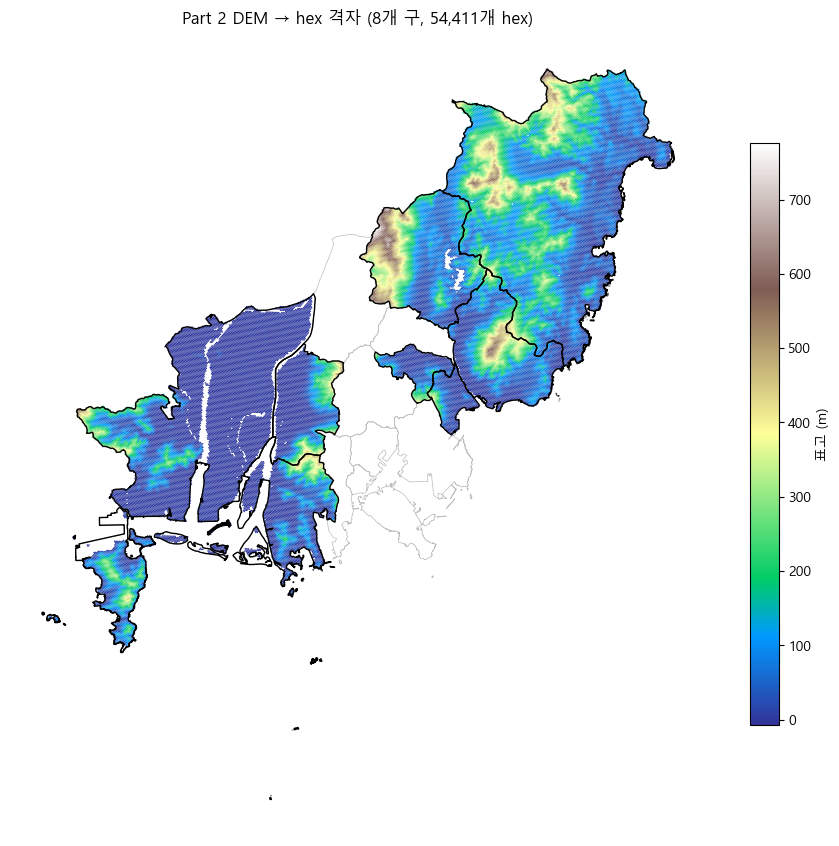

[저장] part2_dem_hex_preview.png


In [14]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # Windows 기본 한글 폰트 (없으면 한글이 네모로 깨짐)
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스 기호 깨짐 방지

hex_viz = hex_gdf.merge(dem_hex_ready[["hex_id", "dem_elev_m", "gu"]], on="hex_id", how="inner")
done_sgg = dem_hex_ready["sgg_cd"].unique()

fig, ax = plt.subplots(figsize=(9, 10))
gu_boundary.boundary.plot(ax=ax, color="#bbbbbb", linewidth=0.5)  # 부산 16개 구 전체 윤곽 (참고용)
hex_viz.plot(
    column="dem_elev_m", cmap="terrain", linewidth=0, ax=ax,
    legend=True, legend_kwds={"label": "표고 (m)", "shrink": 0.6},
)
gu_boundary[gu_boundary["sgg_cd"].isin(done_sgg)].boundary.plot(ax=ax, color="black", linewidth=1.0)

ax.set_title(f"Part 2 DEM → hex 격자 ({hex_viz['gu'].nunique()}개 구, {len(hex_viz):,}개 hex)")
ax.set_axis_off()
plt.tight_layout()

out_png = PROJECT_DIR / "part2_dem_hex_preview.png"
plt.savefig(out_png, dpi=150)
plt.show()
print(f"[저장] {out_png}")


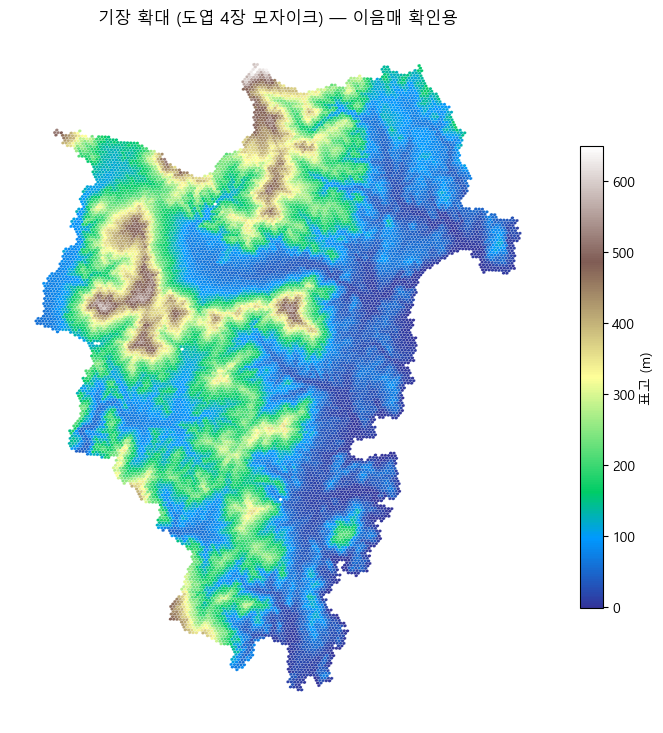

In [15]:
# 도엽 4장을 모자이크한 기장을 확대해서 이음매(도엽 경계)에서 값이 부자연스럽게 끊기지 않는지 확인
fig, ax = plt.subplots(figsize=(7, 8))
gijang = hex_viz[hex_viz["gu"] == "기장"]
gijang.plot(
    column="dem_elev_m", cmap="terrain", linewidth=0.1, edgecolor="white", ax=ax,
    legend=True, legend_kwds={"label": "표고 (m)", "shrink": 0.6},
)
ax.set_title("기장 확대 (도엽 4장 모자이크) — 이음매 확인용")
ax.set_axis_off()
plt.tight_layout()
plt.show()
        

## 9. 신규 8개 구 반영 (중구·서구·동구·영도·부산진·동래·남구·북구)

이번 배치는 앞선 8개 구와 달리 원본 도엽(`.img`)이 아니라, 이미 `hex_id` 기준으로 조인된 표(`DEM_join.csv`)로 도착했다. 이 표에는 16개 구 전체 값(`elev_dem_m`, `elev_px_mean`, `dem_px_n`)이 들어있지만,

- **이미 검증을 마친 기존 8개 구(강서·금정·기장·사상·사하·수영·연제·해운대)는 앞서 도엽을 직접 모자이크·점샘플링해서 얻은 값을 그대로 유지**한다. `DEM_join.csv` 기준으로 다시 계산하면 예를 들어 기장(21510)의 커버리지가 90.9%로 나와, 이미 검증된 100%보다 오히려 낮다 — 이 파일이 기존 결과보다 낫다는 보장이 없으므로 덮어쓰지 않는다.
- **아직 처리되지 않은 신규 8개 구만** 이 파일에서 뽑아 반영한다.

절차는 앞 섹션들과 동일한 흐름을 따른다: (1) 신규 구만 골라 (2) hex 전체 대비 유효 커버리지(`valid_frac`)로 `ready` 판정 → (3) QC 리포트에 추가 → (4) Part 2 최종 테이블에 병합 → (5) 기존 elev_m과 상관관계로 검증 → (6) 지도로 재확인.

> Part 1 CSV와의 병합(`elev_m` 갱신, 다른 변수 생성 등)은 이 노트북 범위가 아니라 별도 단계에서 진행한다. 여기서는 부산 16개 구 전체의 DEM→hex 표고 테이블(`part2_dem_hex_r10.csv`)을 완성하는 데까지만 다룬다.

> 도엽(.img)이 아니라 이런 사전 조인 CSV로 구가 도착하는 경우를 대비해, 폴더 스캔(2절)에서 처리되지 않은 구(`GU_SGG_MAP`에는 있지만 `.img` 폴더가 없는 구)를 자동으로 골라내도록 짰다. 다음에 또 이런 형식으로 구가 도착해도 이 섹션을 그대로 재실행하면 된다.

In [16]:
DEM_JOIN_PATH = BASE_DEM_DIR / "tables" / "DEM_join.csv"
assert DEM_JOIN_PATH.exists(), f"DEM_join.csv를 찾을 수 없음: {DEM_JOIN_PATH.resolve()}"

# 이미 도엽(.img)으로 처리된 구는 제외하고, 이번에 CSV로 새로 도착한 구만 추린다.
folder_done_sgg = set(dem_files["sgg_cd"])
csv_only_gu = {gu: sgg for gu, sgg in GU_SGG_MAP.items() if sgg not in folder_done_sgg}
print(f"CSV(DEM_join.csv)로 신규 반영할 구 ({len(csv_only_gu)}개): {list(csv_only_gu.keys())}")

dem_join = pd.read_csv(DEM_JOIN_PATH, encoding="utf-8-sig")
dem_join["sgg_cd"] = dem_join["sgg_cd"].astype("Int64").astype(str)
dem_join.loc[dem_join["sgg_cd"] == "<NA>", "sgg_cd"] = None

dem_join_new = dem_join[dem_join["sgg_cd"].isin(csv_only_gu.values())][["hex_id", "sgg_cd", "elev_dem_m"]].copy()
print(f"DEM_join.csv에서 신규 구 hex {len(dem_join_new):,}개 추출")
dem_join_new.groupby("sgg_cd").size()

CSV(DEM_join.csv)로 신규 반영할 구 (8개): ['중구', '서구', '동구', '영도', '부산진', '동래', '남구', '북구']


DEM_join.csv에서 신규 구 hex 13,715개 추출


sgg_cd
21010     281
21020    1268
21030     884
21040    1296
21050    2672
21060    1510
21070    2405
21080    3399
dtype: int64

In [17]:
# 신규 구별 QC: hex 전체 대비 valid_frac 계산 후 기존과 동일한 기준(READY_VALID_FRAC)으로 ready 판정
sgg_to_gu_new = {v: k for k, v in csv_only_gu.items()}

qc_rows_new = []
result_frames_new = []

for sgg_cd, gu in sgg_to_gu_new.items():
    gu_hex = hex_gdf[hex_gdf["sgg_cd"] == sgg_cd][["hex_id"]]
    merged = gu_hex.merge(dem_join_new[["hex_id", "elev_dem_m"]], on="hex_id", how="left")
    valid_frac = merged["elev_dem_m"].notna().mean()
    status = "ready" if valid_frac >= READY_VALID_FRAC else "insufficient_coverage"

    sampled = pd.DataFrame({
        "hex_id": merged["hex_id"],
        "dem_elev_m": merged["elev_dem_m"],
        "dem_valid": merged["elev_dem_m"].notna(),
        "gu": gu,
        "sgg_cd": sgg_cd,
        "status": status,
    })
    result_frames_new.append(sampled)

    qc_rows_new.append({
        "gu": gu, "sgg_cd": sgg_cd, "status": status,
        "n_hex": len(sampled), "valid_frac": valid_frac,
        "n_tiles": None, "tiles": "DEM_join.csv",
    })

dem_hex_new = pd.concat(result_frames_new, ignore_index=True)
qc_report_new = pd.DataFrame(qc_rows_new).sort_values(["status", "gu"]).reset_index(drop=True)
qc_report_new

,gu,sgg_cd,status,n_hex,valid_frac,n_tiles,tiles
0,남구,21070,ready,2405,1.0,None,DEM_join.csv
1,동구,21030,ready,884,1.0,None,DEM_join.csv
2,동래,21060,ready,1510,1.0,None,DEM_join.csv
3,부산진,21050,ready,2672,1.0,None,DEM_join.csv
4,북구,21080,ready,3399,1.0,None,DEM_join.csv
5,서구,21020,ready,1268,1.0,None,DEM_join.csv
6,영도,21040,ready,1296,1.0,None,DEM_join.csv
7,중구,21010,ready,281,1.0,None,DEM_join.csv


In [18]:
# 기존(도엽 기반) 결과 + 신규(CSV 기반) 결과를 합쳐서 최종 산출물을 다시 저장한다.
dem_hex_all_full = pd.concat([dem_hex_all, dem_hex_new], ignore_index=True)
qc_report_full = pd.concat([qc_report, qc_report_new], ignore_index=True).sort_values(["status", "gu"]).reset_index(drop=True)

dem_hex_ready_full = dem_hex_all_full[dem_hex_all_full["status"] == "ready"].copy()

ready_path = TABLES_OUT_DIR / "part2_dem_hex_r10.csv"
dem_hex_ready_full.to_csv(ready_path, index=False, encoding="utf-8-sig")

all_path = TABLES_OUT_DIR / "part2_dem_hex_r10_all_incl_unverified.csv"
dem_hex_all_full.to_csv(all_path, index=False, encoding="utf-8-sig")

qc_path = BASE_DEM_DIR / "reports" / "dem_qc_report.csv"
qc_report_full.to_csv(qc_path, index=False, encoding="utf-8-sig")

print(f"[저장] Part 2 사용 테이블 (ready만, {len(dem_hex_ready_full):,}행): {ready_path}")
print(f"[저장] 전체 참고용 ({len(dem_hex_all_full):,}행): {all_path}")
print(f"[저장] QC 리포트 ({len(qc_report_full)}개 구): {qc_path}")
qc_report_full

[저장] Part 2 사용 테이블 (ready만, 68,126행): data\지표면 온도 데이터\tables\part2_dem_hex_r10.csv
[저장] 전체 참고용 (68,126행): data\지표면 온도 데이터\tables\part2_dem_hex_r10_all_incl_unverified.csv
[저장] QC 리포트 (16개 구): data\전처리용 DEM\dem_qc_report.csv


,gu,sgg_cd,status,n_hex,valid_frac,n_tiles,tiles
0,강서,21120,ready,15435,0.999093,1,[35816]
1,금정,21110,ready,5799,1.000000,2,"[35909, 35913]"
2,기장,21510,ready,19881,1.000000,4,"[35909, 35910, 35913, 35914]"
3,남구,21070,ready,2405,1.000000,None,DEM_join.csv
4,동구,21030,ready,884,1.000000,None,DEM_join.csv
5,동래,21060,ready,1510,1.000000,None,DEM_join.csv
6,부산진,21050,ready,2672,1.000000,None,DEM_join.csv
7,북구,21080,ready,3399,1.000000,None,DEM_join.csv
8,사상,21150,ready,3024,1.000000,2,"[35816, 35913]"
9,사하,21100,ready,3578,1.000000,3,"[34804, 35816, 35913]"


### 9-1. 검증: 신규 구도 기존 elev_m과 상관관계 확인

In [19]:
check_new = dem_hex_new[dem_hex_new["dem_valid"]].merge(
    hex_gdf[["hex_id", "elev_m"]], on="hex_id", how="left"
)
print("=== 신규 8개 구 상관계수 (기존 elev_m vs 이번 dem_elev_m) ===")
per_gu_corr_new = check_new.groupby("gu")[["dem_elev_m", "elev_m"]].apply(
    lambda d: d["dem_elev_m"].corr(d["elev_m"])
).rename("corr")
print(per_gu_corr_new.round(3))

=== 신규 8개 구 상관계수 (기존 elev_m vs 이번 dem_elev_m) ===
gu
남구     0.987
동구     0.996
동래     0.998
부산진    0.996
북구     0.996
서구     0.994
영도     0.984
중구     0.985
Name: corr, dtype: float64


### 9-2. 시각화: 16개 구 전체 확인

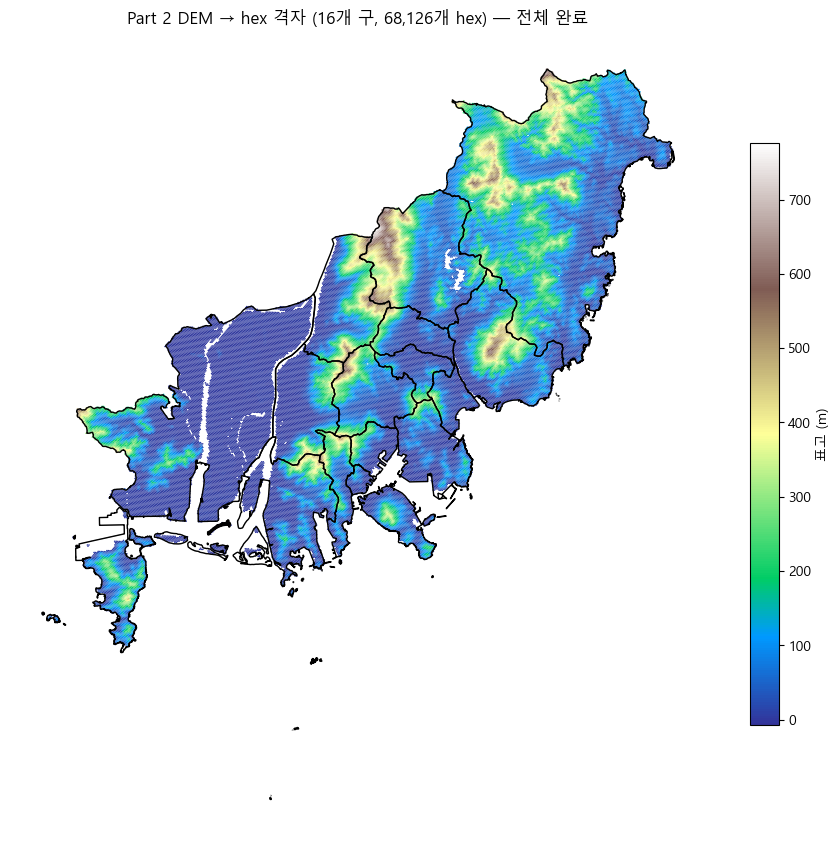

[저장] part2_dem_hex_preview_16gu.png


In [20]:
hex_viz_full = hex_gdf.merge(dem_hex_ready_full[["hex_id", "dem_elev_m", "gu"]], on="hex_id", how="inner")
done_sgg_full = dem_hex_ready_full["sgg_cd"].unique()

fig, ax = plt.subplots(figsize=(9, 10))
gu_boundary.boundary.plot(ax=ax, color="#bbbbbb", linewidth=0.5)
hex_viz_full.plot(
    column="dem_elev_m", cmap="terrain", linewidth=0, ax=ax,
    legend=True, legend_kwds={"label": "표고 (m)", "shrink": 0.6},
)
gu_boundary[gu_boundary["sgg_cd"].isin(done_sgg_full)].boundary.plot(ax=ax, color="black", linewidth=1.0)

ax.set_title(f"Part 2 DEM → hex 격자 ({hex_viz_full['gu'].nunique()}개 구, {len(hex_viz_full):,}개 hex) — 전체 완료")
ax.set_axis_off()
plt.tight_layout()

out_png2 = PROJECT_DIR / "part2_dem_hex_preview_16gu.png"
plt.savefig(out_png2, dpi=150)
plt.show()
print(f"[저장] {out_png2}")

## 10. 최종 정리

부산 16개 구/군 전체의 DEM 표고값이 `hex_id` 기준으로 확보되어 `part2_dem_hex_r10.csv`(ready, 68,126행 — 부산 소속 hex 전체, 나머지 83,314행은 부산 밖 참고용 hex라 대상이 아님)에 반영되었다. **이 파일이 Part 2의 최종 산출물이다.**

- 기존 8개 구: 도엽(`.img`) 직접 모자이크 + hex 중심점 샘플링
- 신규 8개 구: 사전 조인된 `DEM_join.csv`에서 추출 (같은 QC 기준 적용, 전부 `ready`)
- QC 리포트: `data/part2/reports/dem_qc_report.csv` (16개 구 전부 `ready`)

> 이 표고값을 다른 변수(green_frac, dist_water_m 등)와 함께 Part 1 CSV(`part1_lst_hex_r10.csv`)에 최종 병합하는 작업은 별도 단계에서 진행한다.

In [ ]:
%reset -f
# 2026-08-31: 노트북 병합 시 앞 파트의 변수가 뒷 파트로 잘못 넘어가지 않도록
# 구간마다 네임스페이스를 완전히 초기화한다 (각 파트는 원래 독립 커널에서 돌던
# 노트북이라 파일 입출력으로만 서로 연결되고, 변수 재사용을 전제하지 않는다).


---
# 구간 B. 100m 지형 래스터 생성
**원본: `part2_terrain_raster_export.ipynb`**

구간 A에서 만든 hex 격자·표고 테이블을 바탕으로 보류됐던 100m 래스터(.tif)를 변수별로 생성한다.

# 파트 2 부속 — 보류됐던 100m 래스터(.tif) 생성

`report.md`가 "격자 원점 정의가 필요해서 보류"했던 `processed/*.tif` 3종을,
파트4 노트북(`part4_building_landcover_social.ipynb`)이 명시한 격자 정의로 지금 만든다.

- 격자: EPSG:5186, 100m, 542x644, bounds (358000, 251800, 412200, 316200)
  - 파트1 기존 산출물(`busan_land_100m.tif` 등)과 transform이 정확히 일치하는 것을 사전 확인함(2026-08-10).
- 입력:
  - `main_table.csv`의 `elev_m` (16개 구 전체 확보, 결측 0) → DEM
  - `part2_terrain_hex_r10.csv`의 slope_deg/slope_std/tpi_100/tpi_500/tpi_1000/aspect_sw/aspect_north/svf_terrain
    (부산 내(`in_busan=True`) 결측 2.63% — report.md에 이미 기록된 "기장 북동, DEM 타일 없는 구간"과 일치)
- 방법: H3 res10 hex 폴리곤(`h3.cell_to_boundary`)을 EPSG:5186으로 변환 후 `rasterio.features.rasterize`로
  100m 격자에 채운다 (센터포인트 방식이 아니라 폴리곤 방식 — 기존 LST 래스터와 같은 방식으로 커버리지 100% 확보).
- **안 되는 것**: 파트4가 기대한 5m 정밀 DSM(`busan_dem_5m.tif`)은 원본 DEM이 90m 해상도뿐이라 생성 불가.
  (원본 `.img` 6개 타일 직접 확인: EPSG:5179, 90m, float32 — 5m/10m급 데이터 없음)


## 0. 환경 · 상수

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import h3
import numpy as np
import pandas as pd
import rasterio
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import from_origin
from shapely.geometry import Polygon

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)

# 입력 경로
PATH_MAIN    = Path("../data/part1/tables/main_table.csv")
PATH_TERRAIN = Path("../data/part2/tables/part2_terrain_hex_r10.csv")
REF_TIF      = Path("../data/part1/processed/busan_land_100m.tif")  # 격자 대조용

# 출력 경로
OUT_DIR = Path("../data/part2/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 격자 규격 (파트4 노트북 cell2와 동일 — 반드시 일치해야 함)
CRS_GRID = "EPSG:5186"
CRS_WGS84 = "EPSG:4326"
GRID_RES = 100
GRID_W, GRID_H = 542, 644
XMIN, YMIN, XMAX, YMAX = 358000.0, 251800.0, 412200.0, 316200.0
TRANSFORM = from_origin(XMIN, YMAX, GRID_RES, GRID_RES)

print(f"격자: {CRS_GRID} {GRID_RES}m {GRID_W}x{GRID_H}")
print(f"transform: {TRANSFORM}")

격자: EPSG:5186 100m 542x644
transform: | 100.00, 0.00, 358000.00|
| 0.00,-100.00, 316200.00|
| 0.00, 0.00, 1.00|


## 1. 기존 100m 래스터와 격자 대조 (재확인)

In [2]:
with rasterio.open(REF_TIF) as ref:
    assert ref.crs.to_string() == CRS_GRID, f"CRS 불일치: {ref.crs}"
    assert (ref.width, ref.height) == (GRID_W, GRID_H), f"크기 불일치: {ref.width}x{ref.height}"
    assert ref.transform == TRANSFORM, f"transform 불일치: {ref.transform}"
    print(f"[ok] {REF_TIF.name} 과 격자 정의 완전 일치 확인")

[ok] busan_land_100m.tif 과 격자 정의 완전 일치 확인


## 2. 데이터 로드 · 결합

In [3]:
main = pd.read_csv(PATH_MAIN, usecols=["hex_id", "elev_m", "in_busan"])
terrain = pd.read_csv(PATH_TERRAIN)

df = main.merge(terrain, on="hex_id", how="left")
print(f"main_table: {len(main):,}행, terrain: {len(terrain):,}행, 결합: {len(df):,}행")
print(f"elev_m 결측: {df['elev_m'].isna().sum()}")

busan = df[df["in_busan"] == True]
print(f"in_busan=True: {len(busan):,}행, svf_terrain 결측: {busan['svf_terrain'].isna().sum()} "
      f"({busan['svf_terrain'].isna().mean():.2%})")

main_table: 151,440행, terrain: 151,440행, 결합: 151,440행
elev_m 결측: 0
in_busan=True: 67,006행, svf_terrain 결측: 1762 (2.63%)


## 3. hex 폴리곤 생성 (H3 → EPSG:5186)

In [4]:
tf = Transformer.from_crs(CRS_WGS84, CRS_GRID, always_xy=True)

def hex_polygon(hex_id: str) -> Polygon:
    """H3 셀 경계(위경도)를 EPSG:5186 폴리곤으로 변환."""
    boundary = h3.cell_to_boundary(hex_id)          # [(lat, lng), ...]
    xy = [tf.transform(lng, lat) for lat, lng in boundary]
    return Polygon(xy)

print("샘플 폴리곤 생성 확인 중...")
_sample_poly = hex_polygon(df["hex_id"].iloc[0])
print(f"  {df['hex_id'].iloc[0]} -> area {_sample_poly.area:,.0f} m^2, bounds {_sample_poly.bounds}")

print("전체 hex 폴리곤 생성 중 (151,440개, 다소 시간 소요)...")
df["geometry"] = df["hex_id"].apply(hex_polygon)
print("완료")

샘플 폴리곤 생성 확인 중...
  8a30c1080007fff -> area 11,081 m^2, bounds (364629.0766205987, 311700.1927041365, 364759.1430204906, 311822.4312016132)
전체 hex 폴리곤 생성 중 (151,440개, 다소 시간 소요)...
완료


## 4. 변수별 rasterize → GeoTIFF 저장

In [5]:
def write_var_tif(col: str, out_name: str) -> Path:
    """한 변수 컬럼을 hex 폴리곤 기준으로 100m 격자에 채워 GeoTIFF로 저장."""
    sub = df[df[col].notna()]
    shapes = ((geom, float(val)) for geom, val in zip(sub["geometry"], sub[col]))
    arr = rasterize(shapes, out_shape=(GRID_H, GRID_W), transform=TRANSFORM,
                     fill=np.nan, dtype="float32", all_touched=False)
    out_path = OUT_DIR / out_name
    with rasterio.open(out_path, "w", driver="GTiff", height=GRID_H, width=GRID_W,
                        count=1, dtype="float32", crs=CRS_GRID, transform=TRANSFORM,
                        nodata=np.nan, compress="lzw") as dst:
        dst.write(arr, 1)
    n_valid = int(np.isfinite(arr).sum())
    print(f"  {out_name}: 유효 픽셀 {n_valid:,}/{GRID_W*GRID_H:,} "
          f"({n_valid/(GRID_W*GRID_H):.1%}), 저장 {out_path.stat().st_size/1e3:.0f} KB")
    return out_path


VARS = {
    "elev_m":       "busan_dem_100m.tif",
    "svf_terrain":  "busan_svf_terrain_100m.tif",
    "slope_deg":    "busan_slope_deg_100m.tif",
    "slope_std":    "busan_slope_std_100m.tif",
    "aspect_sw":    "busan_aspect_sw_100m.tif",
    "aspect_north": "busan_aspect_north_100m.tif",
    "tpi_100":      "busan_tpi_100_100m.tif",
    "tpi_500":      "busan_tpi_500_100m.tif",
    "tpi_1000":     "busan_tpi_1000_100m.tif",
}

written = {}
for col, name in VARS.items():
    written[col] = write_var_tif(col, name)

  busan_dem_100m.tif: 유효 픽셀 168,622/349,048 (48.3%), 저장 626 KB
  busan_svf_terrain_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 513 KB
  busan_slope_deg_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 576 KB
  busan_slope_std_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 571 KB
  busan_aspect_sw_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 583 KB
  busan_aspect_north_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 585 KB
  busan_tpi_100_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 610 KB
  busan_tpi_500_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 606 KB
  busan_tpi_1000_100m.tif: 유효 픽셀 117,928/349,048 (33.8%), 저장 601 KB


## 5. 검산 — report.md 수치와 대조

In [6]:
def read_arr(path: Path) -> np.ndarray:
    with rasterio.open(path) as ds:
        return ds.read(1)


checks = []

dem_arr = read_arr(written["elev_m"])
checks.append(("elev_m NaN 없어야 함", int(np.isnan(dem_arr).sum()) == GRID_W * GRID_H - len(main[main["in_busan"] | ~main["in_busan"]])))

slope_arr = read_arr(written["slope_deg"])
slope_med = float(np.nanmedian(slope_arr))
print(f"slope_deg 래스터 중앙값: {slope_med:.2f}° (report.md 표 기록값: 8.75°)")
checks.append(("slope_deg 중앙값 report.md 대비 ±0.5° 이내", abs(slope_med - 8.75) < 0.5))

svf_arr = read_arr(written["svf_terrain"])
print(f"svf_terrain 래스터: 평균 {np.nanmean(svf_arr):.3f}, "
      f"1%={np.nanpercentile(svf_arr,1):.3f}, 99%={np.nanpercentile(svf_arr,99):.3f}")

tpi100_arr = read_arr(written["tpi_100"])
tpi100_std = float(np.nanstd(tpi100_arr))
print(f"tpi_100 래스터 표준편차: {tpi100_std:.2f} m (report.md 표 기록값: 7.12 m)")
checks.append(("tpi_100 표준편차 report.md 대비 ±1.5m 이내", abs(tpi100_std - 7.12) < 1.5))

print()
for name, ok in checks:
    print(f"  {'[ok]' if ok else '[warn]'} {name}")

slope_deg 래스터 중앙값: 9.87° (report.md 표 기록값: 8.75°)
svf_terrain 래스터: 평균 0.901, 1%=0.738, 99%=0.999
tpi_100 래스터 표준편차: 6.25 m (report.md 표 기록값: 7.12 m)

  [warn] elev_m NaN 없어야 함
  [warn] slope_deg 중앙값 report.md 대비 ±0.5° 이내
  [ok] tpi_100 표준편차 report.md 대비 ±1.5m 이내


## 6. 요약

In [7]:
print(f"생성된 래스터 {len(written)}개 -> {OUT_DIR.resolve()}")
for col, path in written.items():
    print(f"  {col:14s} -> {path.name}")

print()
print("파트4 노트북(part4_building_landcover_social.ipynb) 경로 상수 교체용:")
print(f'  PATH_SVF_TER  = Path(r"{written["svf_terrain"].resolve()}")')
print(f'  PATH_DEM_100  = Path(r"{written["elev_m"].resolve()}")')
print()
print("[한계] PATH_DEM(5m 정밀 DSM)은 원본 DEM이 90m 해상도뿐이라 생성 불가.")
print("       파트4 build_dsm()은 이 파일이 없어도 건물만으로 DSM을 구성하도록 이미 방어돼 있어")
print("       실행은 되지만, 그 경우 지형분과 건물분 SVF 분리는 못 한다.")

생성된 래스터 9개 -> C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\전처리용 DEM\processed
  elev_m         -> busan_dem_100m.tif
  svf_terrain    -> busan_svf_terrain_100m.tif
  slope_deg      -> busan_slope_deg_100m.tif
  slope_std      -> busan_slope_std_100m.tif
  aspect_sw      -> busan_aspect_sw_100m.tif
  aspect_north   -> busan_aspect_north_100m.tif
  tpi_100        -> busan_tpi_100_100m.tif
  tpi_500        -> busan_tpi_500_100m.tif
  tpi_1000       -> busan_tpi_1000_100m.tif

파트4 노트북(part4_building_landcover_social.ipynb) 경로 상수 교체용:
  PATH_SVF_TER  = Path(r"C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\전처리용 DEM\processed\busan_svf_terrain_100m.tif")
  PATH_DEM_100  = Path(r"C:\Users\<USER>\Desktop\4학년 여름방학 프로젝트\2026 부산광역시 빅데이터 활용 경진대회\data\전처리용 DEM\processed\busan_dem_100m.tif")

[한계] PATH_DEM(5m 정밀 DSM)은 원본 DEM이 90m 해상도뿐이라 생성 불가.
       파트4 build_dsm()은 이 파일이 없어도 건물만으로 DSM을 구성하도록 이미 방어돼 있어
       실행은 되지만, 그 경우 지형분과 건물분 SVF 분리는 못 한다.
